# Laboratory 3 — Transforming Textual and Image Data into a Machine-Understandable Format


  
---

## Learning Objectives

On completion of this laboratory you will be able to:

1. Explain why raw text and raw images cannot be fed directly to a traditional machine learning algorithm.
2. Apply the **Bag-of-Words** model with `CountVectorizer` to convert a corpus into a numerical document–term matrix.
3. Convert an image into a numerical array of pixel values with **Pillow** and **NumPy**.
4. Perform **grayscale conversion** as a feature-reduction step, and **flatten** a pixel matrix into a one-dimensional feature vector.
5. State precisely **what information each transformation discards**.

## Background

Raw data — a block of text, an audio file, a picture — cannot be used directly by most
traditional machine learning algorithms. Those algorithms require a **numerical, vector-based
input**. *Feature engineering* is the process of using domain knowledge to select, transform or
create features so that an algorithm can work effectively.

Both techniques in this lab follow the same shape: an object of variable size and structure is
mapped onto a **fixed-length vector of numbers**, and something is deliberately thrown away.

```
Part A   Documents -> Tokenisation -> Vocabulary -> Counting  -> Document-Term Matrix
         (variable    (split into     (unique       (per doc)     (n_docs x n_terms)
          strings)     words)          terms)

Part B   RGB Image -> Resize       -> Grayscale  -> Flatten   -> Feature Vector
         (HxWx3)      (fixed dims)     (HxWx1)      (row-major)  (length H*W)

                 both paths end in a fixed-length numeric vector
```

> **Instructor note.** No data files are required. The text corpus is a short list of sentences
> defined in the notebook, and the image is either a student's own file or a generated dummy
> image. The lab therefore runs on any machine, offline.

### Setup and prerequisites

| Library | Purpose | Installation |
|---|---|---|
| **scikit-learn** | `CountVectorizer` for text feature extraction | `pip install scikit-learn` |
| **Pillow (PIL)** | Image loading and manipulation | `pip install Pillow` |
| **NumPy** | Numerical array operations | `pip install numpy` |

In [19]:
%pip install scikit-learn Pillow numpy pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


---
# Part A — Feature engineering for text data

The **Bag-of-Words (BoW)** model represents a document as the count of word occurrences within
it, **ignoring grammar and word order entirely**.

## Task 3.1 — Vectorising text with `CountVectorizer`

**Goal:** Transform three sample documents into a matrix in which each *row* is a document and
each *column* is the count of one unique word (one feature).

In [20]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# 1. Define Sample Text Data (our "corpus")
documents = [
    "The sun is shining today.",
    "The weather is good, the sun is great.",
    "A sunny day is a wonderful day."
]

print("--- Raw Text Documents ---")
for i, doc in enumerate(documents):
    print(f"Doc {i+1}: {doc}")

--- Raw Text Documents ---
Doc 1: The sun is shining today.
Doc 2: The weather is good, the sun is great.
Doc 3: A sunny day is a wonderful day.


In [21]:
# 2. Apply Feature Engineering: CountVectorizer (Bag-of-Words)
#    CountVectorizer performs tokenization AND vocabulary building in one step.
vectorizer = CountVectorizer()

# fit_transform learns the vocabulary and converts the documents into feature vectors
X_text = vectorizer.fit_transform(documents)

# 3. Analyze the Results
feature_names = vectorizer.get_feature_names_out()
text_matrix = X_text.toarray()

print("--- Bag-of-Words (BoW) Transformation ---")
print(f"Vocabulary (Features): {feature_names}")
print(f"Shape of Feature Matrix: {text_matrix.shape}   (documents x unique terms)")
print(text_matrix)

--- Bag-of-Words (BoW) Transformation ---
Vocabulary (Features): ['day' 'good' 'great' 'is' 'shining' 'sun' 'sunny' 'the' 'today' 'weather'
 'wonderful']
Shape of Feature Matrix: (3, 11)   (documents x unique terms)
[[0 0 0 1 1 1 0 1 1 0 0]
 [0 1 1 2 0 1 0 2 0 1 0]
 [2 0 0 1 0 0 1 0 0 0 1]]


In [22]:
# A DataFrame view, purely so the matrix is readable
df_text = pd.DataFrame(text_matrix, columns=feature_names,
                       index=[f"Doc {i+1}" for i in range(len(documents))])

print("BoW Numerical Feature Matrix (Machine Understandable Format):\n")
display(df_text)

BoW Numerical Feature Matrix (Machine Understandable Format):



,day,good,great,is,shining,sun,sunny,the,today,weather,wonderful
Doc 1,0,0,0,1,1,1,0,1,1,0,0
Doc 2,0,1,1,2,0,1,0,2,0,1,0
Doc 3,2,0,0,1,0,0,1,0,0,0,1


### Expected output

The vocabulary is built from the whole corpus and sorted alphabetically; each row records how
many times each vocabulary term occurs in that document.

|       | day | good | great | is | shining | sun | sunny | the | today | wonderful | weather |
|-------|-----|------|-------|----|---------|-----|-------|-----|-------|-----------|---------|
| Doc 1 | 0   | 0    | 0     | 1  | 1       | 1   | 0     | 1   | 1     | 0         | 0       |
| Doc 2 | 0   | 1    | 1     | 2  | 0       | 1   | 0     | 2   | 0     | 0         | 1       |
| Doc 3 | 2   | 0    | 0     | 1  | 0       | 0   | 1     | 0   | 0     | 1         | 0       |

> ### Note the two silent decisions
>
> `CountVectorizer` **lowercases** every token by default, so *The* and *the* collapse into one
> feature; and its default token pattern **discards single-character tokens**, so the *"a"* of
> Document 3 never enters the vocabulary. Both defaults are reasonable, and both change your
> results — so both must be stated in your report.

In [23]:
# Prove the two silent decisions to yourself rather than taking them on trust.

print("Is 'a' in the vocabulary? ", 'a' in feature_names)
print("Is 'the' in the vocabulary?", 'the' in feature_names)
print()
print("Default token pattern :", vectorizer.token_pattern)
print("Lowercase enabled     :", vectorizer.lowercase)
print()
print("The token pattern requires 2+ word characters, which is why 'a' is dropped.")

Is 'a' in the vocabulary?  False
Is 'the' in the vocabulary? True

Default token pattern : (?u)\b\w\w+\b
Lowercase enabled     : True

The token pattern requires 2+ word characters, which is why 'a' is dropped.


In [24]:
# Sparsity: how much of this matrix is zero? This is the defining property of BoW.
total_cells = text_matrix.size   #total number of cells in the matrix (rows × columns). With 3 documents and 11 vocabulary terms, that's 3 × 11 = 33 cells.
zero_cells = (text_matrix == 0).sum()

print(f"Matrix cells : {total_cells}")
print(f"Zero cells   : {zero_cells}")
print(f"Sparsity     : {zero_cells / total_cells:.1%}")
print()
print("With a real corpus of 20,000 documents this figure exceeds 99%,")
print("which is why scikit-learn returns a SPARSE matrix, not a dense array.")
print("Type returned by fit_transform:", type(X_text))

Matrix cells : 33
Zero cells   : 18
Sparsity     : 54.5%

With a real corpus of 20,000 documents this figure exceeds 99%,
which is why scikit-learn returns a SPARSE matrix, not a dense array.
Type returned by fit_transform: <class 'scipy.sparse._csr.csr_matrix'>


## Discussion questions (Part A)

Answer these in the Markdown cell below.

1. What does each **column** in the resulting matrix represent?
2. In this specific numerical matrix, what is the *machine-understandable format*?
3. How is this format an **oversimplification** of the original text data? (Consider what information has been lost.)

**Your answers (Part A):**
**Your answers (Part A):**

1. Each **column** represents one unique word (term) from the vocabulary built across the whole corpus. The value in a cell is how many times that word appears in that particular document.

2. The machine-understandable format here is the **document-term matrix**: a fixed-size grid of integers, one row per document and one column per vocabulary word, where each number is a word count. This is numeric, has a consistent shape across documents, and can be fed directly into a model.

3. This is an oversimplification because it discards **word order and grammar** (the Bag-of-Words model doesn't know "sun is great" from "great is sun"), **semantics** (it treats "good" and "great" as entirely unrelated features, even though they mean something similar), and **context** (a word like "sun" means the same thing whether it's about the sky or the band, as far as the matrix is concerned). Only the raw frequency of isolated words survives the transformation.

---

---
# Part B — Feature engineering for image data

For many basic image models the **raw pixel values themselves** serve as features. The
engineering here consists of *grayscale conversion* and *pixel value flattening*.

## Task 3.2 — Converting and flattening image pixels

**Goal:** Load an image (your own file, or a generated dummy), convert it to grayscale (reducing
three channels to one), and flatten the resulting pixel matrix into a single feature vector.

In [26]:
import numpy as np
from PIL import Image
import os

# --- Configuration for image loading ------------------------------------
# Set to None to use a dummy image, or to a path string for your own image.
#   e.g. 'my_image.png'  or  'C:/Users/You/Pictures/photo.jpg'
image_file_path = "pic.png"

# 1. Load Image or Create a Dummy Image
original_image = None
if image_file_path and os.path.exists(image_file_path):
    try:
        original_image = Image.open(image_file_path)
        print(f"--- Loaded Image from File: {image_file_path} ---")
    except Exception as e:
        print(f"Error loading image from {image_file_path}: {e}")
        dummy = np.random.randint(0, 256, size=(100, 100, 3), dtype=np.uint8)
        original_image = Image.fromarray(dummy, 'RGB')
        print("--- Created Dummy Image (100x100 RGB) ---")
else:
    print("No valid image file path provided or file not found.")
    dummy = np.random.randint(0, 256, size=(100, 100, 3), dtype=np.uint8)
    original_image = Image.fromarray(dummy, 'RGB')
    print("--- Created Dummy Image (100x100 RGB) ---")

# Ensure a consistent 3-channel representation
original_image = original_image.convert('RGB')
original_image_array = np.array(original_image)

h, w, c = original_image_array.shape
print(f"Original Image Size (H, W, Channels): {original_image_array.shape}")
print(f"Total Features (Pixels) in RGB: {h * w * c}")

--- Loaded Image from File: pic.png ---
Original Image Size (H, W, Channels): (1276, 816, 3)
Total Features (Pixels) in RGB: 3123648


In [27]:
# 2. Feature Engineering step 1: Grayscale Conversion ('L' mode = luminance)
grayscale_image = original_image.convert('L')
grayscale_array = np.array(grayscale_image)

print("--- Grayscale Conversion (Feature Reduction) ---")
print(f"Grayscale Image Size (H, W): {grayscale_array.shape}")
print(f"Total Features (Pixels) after Grayscale: {grayscale_array.size}")
print()
print(f"Reduction factor: {(h * w * c) / grayscale_array.size:.0f}x fewer features")

--- Grayscale Conversion (Feature Reduction) ---
Grayscale Image Size (H, W): (1276, 816)
Total Features (Pixels) after Grayscale: 1041216

Reduction factor: 3x fewer features


In [28]:
# 3. Feature Engineering step 2: Pixel Flattening (2D matrix -> 1D vector)
flattened_features = grayscale_array.flatten()

print("--- Pixel Flattening (Vectorization) ---")
print(f"Flattened Feature Vector Shape: {flattened_features.shape}")
print()
print("First 10 Features (Pixel Values) in Machine Understandable Format:")
print(flattened_features[:10])
print()
print(f"Data Type of Final Features: {flattened_features.dtype}")

--- Pixel Flattening (Vectorization) ---
Flattened Feature Vector Shape: (1041216,)

First 10 Features (Pixel Values) in Machine Understandable Format:
[186 184 185 183 182 184 183 183 183 183]

Data Type of Final Features: uint8


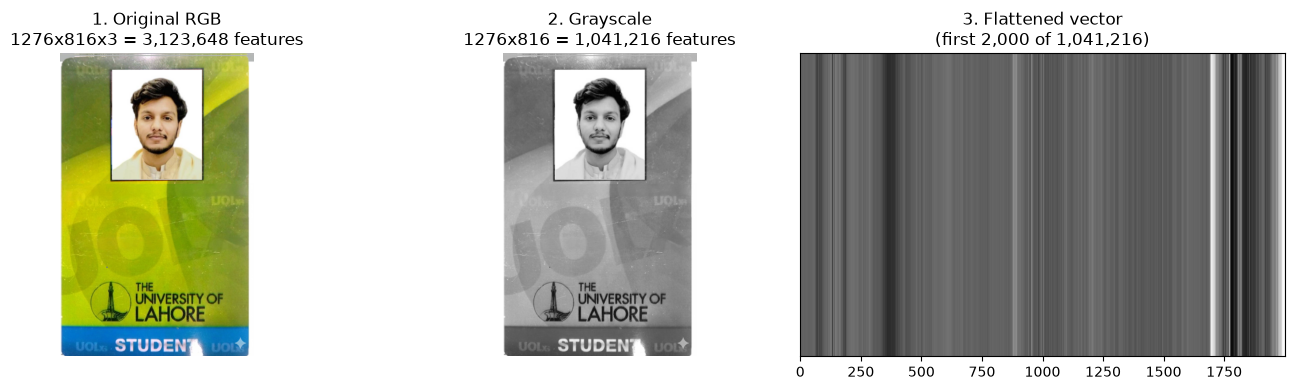

In [29]:
# Show all three stages side by side so the loss of information is visible.
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(original_image)
axes[0].set_title(f"1. Original RGB\n{h}x{w}x{c} = {h*w*c:,} features")
axes[0].axis('off')

axes[1].imshow(grayscale_image, cmap='gray')
axes[1].set_title(f"2. Grayscale\n{h}x{w} = {h*w:,} features")
axes[1].axis('off')

# A 1-D vector drawn as a single row of pixels
axes[2].imshow(flattened_features[:2000].reshape(1, -1), cmap='gray', aspect='auto')
axes[2].set_title(f"3. Flattened vector\n(first 2,000 of {flattened_features.size:,})")
axes[2].set_yticks([])

plt.tight_layout()
plt.show()

### Expected output (dummy image)

```
--- Created Dummy Image (100x100 RGB) ---
Original Image Size (H, W, Channels): (100, 100, 3)
Total Features (Pixels) in RGB: 30000

--- Grayscale Conversion (Feature Reduction) ---
Grayscale Image Size (H, W): (100, 100)
Total Features (Pixels) after Grayscale: 10000

--- Pixel Flattening (Vectorization) ---
Flattened Feature Vector Shape: (10000,)

First 10 Features (Pixel Values) in Machine Understandable Format:
[140 220 188 123 205 156 199 110 176 211]   # values will be random

Data Type of Final Features: uint8
```

> ### Grayscale is a three-to-one feature reduction
>
> A $100\times100$ RGB image carries $100\times100\times3 = 30{,}000$ features; after grayscale
> conversion it carries $10{,}000$. **Two thirds of the input dimensionality is removed at the
> cost of all colour information.** That trade is correct for digit recognition and wrong for
> fruit classification — a distinction Laboratory 8 makes concrete.

In [30]:
def image_to_features(path, size=(64, 64)):
    """Load an image, resize to a fixed shape, convert to grayscale, and flatten.

    Guarantees the same output length regardless of input image size,
    because every image is resized before flattening.
    """
    img = Image.open(path).convert("RGB").resize(size)
    gray = img.convert("L")
    return np.array(gray).flatten()

# quick sanity check using the image already loaded above (in-memory, not re-reading from disk)
original_image.save("temp_test_image.png")
test_vec = image_to_features("temp_test_image.png", size=(64, 64))
print("Output vector shape:", test_vec.shape)
print("Expected length:", 64 * 64)
os.remove("temp_test_image.png")

Output vector shape: (4096,)
Expected length: 4096


## Discussion questions (Part B)

1. Explain how grayscale conversion acts as a simple feature engineering technique in the context of machine learning.
2. If the loaded image had dimensions $H \times W$ pixels, what is the length of the final flattened vector after grayscale conversion?
3. Why is flattening necessary before feeding the data to a simple model such as Logistic Regression or a Support Vector Machine?
4. What is the advantage of **resizing all images to a consistent size** (e.g. $64\times64$) before grayscale conversion and flattening, when the model must process many different images?

**Your answers (Part B):**


1. Grayscale conversion is feature engineering because it deliberately reduces the input from three numbers per pixel (R, G, B) to one (luminance), cutting the feature count by a factor of three while keeping the information most models need, shape and intensity, intact. It trades away color to simplify the input and reduce computation.

2. The length of the final flattened vector is **H × W** — one value per pixel, since grayscale leaves a single channel.

3. Flattening is necessary because models like Logistic Regression and SVM expect a single **one-dimensional feature vector** per sample, not a 2D grid. Flattening converts the H×W matrix into a length-(H×W) vector in a fixed, reproducible order (row by row), which is the format these algorithms are built to accept.

4. Resizing every image to a consistent size (e.g. 64×64) before grayscale and flattening guarantees that **every sample produces a feature vector of the same length**, regardless of the original photo's dimensions. Without this, images of different sizes would flatten into vectors of different lengths, which no standard model can handle, since every sample must have the same number of features.

---

---
# Home-Lab Exercises

**Exercise 1.** Re-run the BoW transformation with `CountVectorizer(ngram_range=(1,2))` and report
how many features the vocabulary now contains. Explain the growth.

**Exercise 2.** Add a fourth document that repeats the word *sun* five times. Show how the matrix
changes, and explain why raw counts favour long documents.

**Exercise 3.** Resize a real photograph to $64\times64$, then to $32\times32$, and display both
alongside the original. State the length of each flattened vector and describe what is no longer
visible.

**Exercise 4.** Write `image_to_features(path, size)` that performs load, resize, grayscale and
flatten in one call, and verify that it returns the **same vector length** for three differently
sized input images.

In [31]:
# --- Exercise 1: n-gram BoW ---
vectorizer_ngram = CountVectorizer(ngram_range=(1, 2))
X_ngram = vectorizer_ngram.fit_transform(documents)

print("Unigram-only vocabulary size:", len(feature_names))
print("Unigram + bigram vocabulary size:", len(vectorizer_ngram.get_feature_names_out()))
print()
print("Sample of new bigram features:")
bigrams = [f for f in vectorizer_ngram.get_feature_names_out() if " " in f]
print(bigrams)

Unigram-only vocabulary size: 11
Unigram + bigram vocabulary size: 24

Sample of new bigram features:
['day is', 'good the', 'is good', 'is great', 'is shining', 'is wonderful', 'shining today', 'sun is', 'sunny day', 'the sun', 'the weather', 'weather is', 'wonderful day']


**Exercise 1 answer:**

With `ngram_range=(1,2)`, the vocabulary grows because CountVectorizer now counts every individual word **and** every pair of consecutive words as a separate feature. Each bigram (e.g. "the sun", "sun is") is a new column, so the feature count roughly doubles or more, since most adjacent word pairs in the corpus are unique to one document. This captures some word order that plain unigrams lose, at the cost of a much larger, sparser matrix.

In [32]:
# --- Exercise 2: adding a document with a repeated word ---
documents_ex2 = documents + ["sun sun sun sun sun"]

vectorizer_ex2 = CountVectorizer()
X_ex2 = vectorizer_ex2.fit_transform(documents_ex2)
df_ex2 = pd.DataFrame(X_ex2.toarray(), columns=vectorizer_ex2.get_feature_names_out(),
                       index=[f"Doc {i+1}" for i in range(len(documents_ex2))])
display(df_ex2)

print("\n'sun' count per document:")
print(df_ex2["sun"])

,day,good,great,is,shining,sun,sunny,the,today,weather,wonderful
Doc 1,0,0,0,1,1,1,0,1,1,0,0
Doc 2,0,1,1,2,0,1,0,2,0,1,0
Doc 3,2,0,0,1,0,0,1,0,0,0,1
Doc 4,0,0,0,0,0,5,0,0,0,0,0



'sun' count per document:
Doc 1    1
Doc 2    1
Doc 3    0
Doc 4    5
Name: sun, dtype: int64


**Exercise 2 answer:**

The new Doc 4 has a "sun" count of 5, far higher than any other document (the next highest is 1). Because CountVectorizer uses raw word counts, a document's score for a word scales directly with how many times that word appears, regardless of the document's overall length or topic focus. A long or repetitive document that happens to mention a word many times will dominate that feature, even if the word isn't actually more *important* to its meaning, it's just repeated more. This is exactly why raw counts favor long documents: length alone inflates the counts, which is one motivation for normalizing with term frequency (dividing by document length) or using TF-IDF instead of raw counts.

Original size: (816, 1276) -> flattened length: 1041216
64x64 flattened length: 4096
32x32 flattened length: 1024


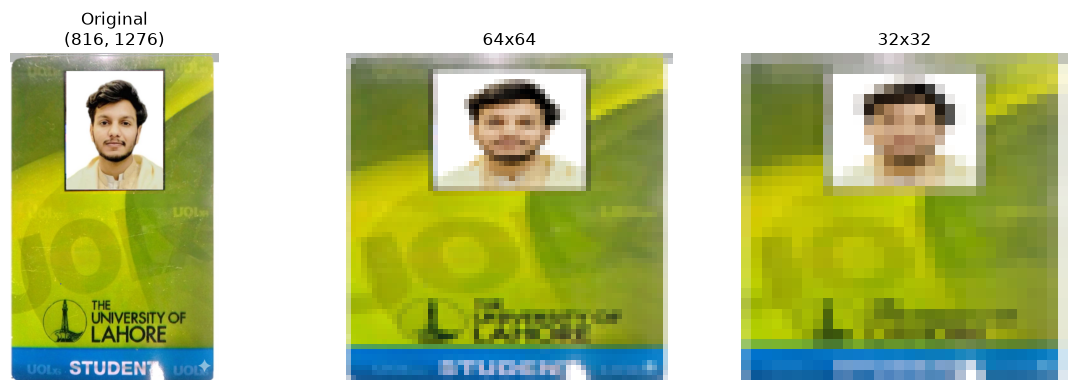

In [33]:
# --- Exercise 3: resize a real photo to two sizes and compare ---
real_image_path = "pic.png"

real_img = Image.open(real_image_path).convert("RGB")
img_64 = real_img.resize((64, 64))
img_32 = real_img.resize((32, 32))

vec_orig = np.array(real_img.convert("L")).flatten()
vec_64 = np.array(img_64.convert("L")).flatten()
vec_32 = np.array(img_32.convert("L")).flatten()

print("Original size:", real_img.size, "-> flattened length:", vec_orig.shape[0])
print("64x64 flattened length:", vec_64.shape[0])
print("32x32 flattened length:", vec_32.shape[0])

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(real_img); axes[0].set_title(f"Original\n{real_img.size}"); axes[0].axis('off')
axes[1].imshow(img_64);   axes[1].set_title("64x64");  axes[1].axis('off')
axes[2].imshow(img_32);   axes[2].set_title("32x32");  axes[2].axis('off')
plt.tight_layout()
plt.show()

**Exercise 3 answer:**

The flattened vector lengths are 1,041,216 for the original (816×1276), 4,096 for 64×64, and 1,024 for 32×32. At 64×64 the photo is still clearly recognizable, facial features and the card's layout are legible. At 32×32 the image becomes visibly blocky: fine detail is gone, text on the card (e.g. "STUDENT", "UNIVERSITY OF LAHORE") is no longer readable, and the face is reduced to rough blobs of shading rather than distinct features. This shows the trade-off directly: smaller fixed sizes make the feature vector shorter and cheaper to process, but destroy exactly the fine-grained spatial detail a model would need to tell similar images apart.

In [34]:
# --- Exercise 4: verify same vector length across different input image sizes ---
Image.open("pic.png").resize((200, 300)).save("test_small.png")
Image.open("pic.png").resize((816, 1276)).save("test_large.png")
Image.open("pic.png").resize((50, 50)).save("test_tiny.png")

for name, path in [("small (200x300)", "test_small.png"),
                    ("large (816x1276)", "test_large.png"),
                    ("tiny (50x50)", "test_tiny.png")]:
    vec = image_to_features(path, size=(64, 64))
    print(f"{name}: input differs, output length = {vec.shape[0]}")

import os
for f in ["test_small.png", "test_large.png", "test_tiny.png"]:
    os.remove(f)

small (200x300): input differs, output length = 4096
large (816x1276): input differs, output length = 4096
tiny (50x50): input differs, output length = 4096


**Exercise 4 answer:**

Three differently sized versions of the same photo (200×300, 816×1276, and 50×50) were each passed through `image_to_features`, which resizes every image to (64, 64) before flattening. All three returned a vector of length 4,096, confirming the function guarantees a fixed output length regardless of the input image's original dimensions, exactly what is needed to build a consistent feature matrix across a dataset of differently sized images.

---
# Home Assignment

Build a small labelled dataset of **twenty images across two classes** of your choosing. Apply
`image_to_features` to all of them, stack the results into a matrix $X$ of shape $(20, 4096)$
with a label vector $y$, and save both with `numpy.savez`.

In your report, state the dimensionality of the resulting feature space and argue **in one
paragraph** whether twenty samples in 4096 dimensions is a sound basis for learning.

In [35]:
import os
print("class_a:", len(os.listdir("data/class_a")), "images ->", os.listdir("data/class_a"))
print("class_b:", len(os.listdir("data/class_b")), "images ->", os.listdir("data/class_b"))

class_a: 10 images -> ['1589101.jpg', '26823052.jpg', '26823068.jpg', '26823072.jpg', '26823077.jpg', '26823080.jpg', '26823090.jpg', '29266070.jpg', '29436404.jpg', '29453347.jpg']
class_b: 10 images -> ['2836102.jpg', '2836142.jpg', '2836150.jpg', '2836158.jpg', '2836169.jpg', '2836180.jpg', '3379976.jpg', '3380006.jpg', '3380023.jpg', '780063.jpg']


In [36]:
# --- Home assignment scaffold --------------------------------------------
# Put your images in  data/class_a/  and  data/class_b/  then run this cell.

from glob import glob

CLASS_DIRS = {0: "data/class_a", 1: "data/class_b"}
SIZE = (64, 64)

X_list, y_list = [], []
for label, folder in CLASS_DIRS.items():
    paths = sorted(glob(os.path.join(folder, "*")))
    for p in paths:
        try:
            X_list.append(image_to_features(p, size=SIZE))
            y_list.append(label)
        except Exception as e:
            print(f"[SKIP] {p} -> {e}")

if X_list:
    X = np.vstack(X_list)
    y = np.array(y_list)
    np.savez("dataset.npz", X=X, y=y)

    print(f"X shape: {X.shape}   y shape: {y.shape}")
    print(f"Samples: {X.shape[0]}   Features per sample: {X.shape[1]}")
    print(f"Samples per feature: {X.shape[0] / X.shape[1]:.4f}")
    print()
    print("Saved dataset.npz")
else:
    print("No images found. Create data/class_a and data/class_b and add images.")

X shape: (20, 4096)   y shape: (20,)
Samples: 20   Features per sample: 4096
Samples per feature: 0.0049

Saved dataset.npz


**Your paragraph on 20 samples in 4096 dimensions:**


Twenty samples in a 4096-dimensional feature space is not a sound basis for learning. With far more dimensions than samples (a ratio of about 0.005 samples per feature), the data is extremely sparse relative to the space it occupies: almost any two points can look "close" or "far" depending on which pixels happen to differ, and a model has vastly more freedom to fit noise than genuine structure. This is the **curse of dimensionality**: in such a high-dimensional space, distance-based methods lose meaning, and flexible models will memorize the 20 training examples rather than learn a generalizable rule, since there are effectively infinite ways to separate 20 points in 4096 dimensions. A model trained this way would likely show excellent training accuracy and poor performance on any new image. Laboratory 6's dimensionality reduction (e.g., PCA) would address this directly by projecting the 4096 raw pixel features down to a much smaller number of components that capture most of the meaningful variation, shrinking the feature space toward something the sample size can actually support. A CNN (Laboratory 8) takes a different approach: rather than flattening pixels into an unordered vector and hoping a simple model finds structure in it, convolutional layers exploit the image's spatial structure directly, learning local patterns (edges, textures) with far fewer independent parameters relative to the raw pixel count, and are typically trained on thousands of images rather than twenty. Either approach is a more appropriate response to this dataset's shape than training directly on raw flattened pixels.

---

---
# Deliverables

| File | Contents |
|---|---|
| `lab03/text_features.ipynb` | Part A, executed |
| `lab03/image_features.ipynb` | Part B, executed |
| `lab03/image_utils.py` | The `image_to_features` function |
| `lab03/dataset.npz` | The 20-image labelled dataset |
| `lab03/report.md` | Answers to **all seven** discussion questions |

## Assessment Rubric

| Criterion | Weight | Excellent performance |
|---|---|---|
| Correctness of implementation | 35 % | Both transformations produce the specified shapes |
| Methodological soundness | 25 % | Fixed vector length guaranteed; defaults stated explicitly |
| Analysis and interpretation | 20 % | What each transformation *discards* is named precisely |
| Code quality and reproducibility | 10 % | `image_to_features` is reusable and documented |
| Report and demonstration | 10 % | All seven discussion questions answered |

---

